# Naive Bayes

In [33]:
import numpy as numpy
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import time
import os
import pickle
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

### leer el Dataset

In [2]:
df= pd.read_csv("/workspaces/infoasir20-primer-algoritmo/data/raw/playstore_reviews.csv")
df


,package_name,review,polarity
0,com.facebook.katana,privacy at least put some option appear offli...,0
1,com.facebook.katana,"messenger issues ever since the last update, ...",0
2,com.facebook.katana,profile any time my wife or anybody has more ...,0
3,com.facebook.katana,the new features suck for those of us who don...,0
4,com.facebook.katana,forced reload on uploading pic on replying co...,0
...,...,...,...
886,com.rovio.angrybirds,loved it i loooooooooooooovvved it because it...,1
887,com.rovio.angrybirds,all time legendary game the birthday party le...,1
888,com.rovio.angrybirds,ads are way to heavy listen to the bad review...,0
889,com.rovio.angrybirds,fun works perfectly well. ads aren't as annoy...,1


### 2: Estudio de variables y su contenido

> En este caso, tenemos solo 3 variables: 2 predictoras y una etiqueta dicotómica. De las dos predictoras, realmente solo nos interesa la parte del comentario, ya que el hecho de clasificar un comentario en positivo o negativo dependerá de su contenido, no de la aplicación de la que se haya escrito

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   package_name  891 non-null    object
 1   review        891 non-null    object
 2   polarity      891 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 21.0+ KB


In [4]:
df.describe()

,polarity
count,891.000000
mean,0.344557
std,0.475490
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [5]:
df.shape

(891, 3)

In [6]:
df.columns.tolist()

['package_name', 'review', 'polarity']

In [7]:
df.iloc[:, -1].value_counts()

polarity
0    584
1    307
Name: count, dtype: int64

In [8]:
df.isnull().sum()

package_name    0
review          0
polarity        0
dtype: int64

### 3- Limpiamos los datos.

> Sin embargo, aunque no hagamos un EDA no podemos trabajar con texto plano, antes hay que procesarlo. Este proceso consta de varios pasos:

In [9]:
text_column = df.columns[1]  # la segunda columna es la de texto
text_column

'review'

In [10]:
target_column = df.columns[-1] # la última columna es la de la etiqueta
target_column

'polarity'

In [11]:
df[text_column] = df[text_column].str.strip().str.lower()

In [12]:
df[text_column].head(3).tolist()

["privacy at least put some option appear offline. i mean for some people like me it's a big pressure to be seen online like you need to response on every message or else you be called seenzone only. if only i wanna do on facebook is to read on my newsfeed and just wanna response on message i want to. pls reconsidered my review. i tried to turn off chat but still can see me as online.",
 "messenger issues ever since the last update, initial received messages don't get pushed to the messenger app and you don't get notification in the facebook app or messenger app. you open the facebook app and happen to see you have a message. you have to click the icon and it opens messenger. subsequent messages go through messenger app, unless you close the chat head... then you start over with no notification and having to go through the facebook app.",
 "profile any time my wife or anybody has more than one post and i view them it would take me to there profile so that i can view them all at once. n

## Recuerda
> Cuando trabajamos con textos como en este caso, no tiene sentido hacer un EDA, el proceso es diferente, ya que la única variable que nos interesa es la que contiene el texto. En otros casos en los que el texto formase parte de un conjunto complejo con otras variables predictoras numéricas y el objetivo de predicción sea distinto, entonces tiene sentido aplicar un EDA.

### 4- Train-Test Split

In [13]:
x = df[text_column]
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Training target distribution:\n{y_train.value_counts()}")
print(f"Test target distribution:\n{y_test.value_counts()}")



Training set size: 712
Test set size: 179
Training target distribution:
polarity
0    467
1    245
Name: count, dtype: int64
Test target distribution:
polarity
0    117
1     62
Name: count, dtype: int64


### Vectorizamos

In [14]:
# Configuración del vectorizador de texto
vec_model = CountVectorizer(
    stop_words="english",    # que ignore las palabras muy comunes en inglés (the, is, and, at, on…)
    max_features=5000,       # Limitamos el número de características a las 5000 más comunes
    lowercase=True,          # Convertir todo a minúsculas
    token_pattern=r'\b\w+\b' # Tokenización básica por palabras
)

In [15]:
X_train_vec = vec_model.fit_transform(X_train).toarray() 
X_test_vec = vec_model.transform(X_test).toarray()

In [16]:
X_train_vec.shape

(712, 3315)

In [17]:
X_test_vec.shape

(179, 3315)

In [18]:
{len(vec_model.get_feature_names_out())}

{3315}

In [19]:
vec_model.get_feature_names_out()[:10]

array(['0', '04', '0x', '1', '10', '100', '101', '11', '113mb', '1186'],
      dtype=object)

### ¡Preprocesamiento completo!
Nuestros datos de texto ya están listos para el aprendizaje automático:

> Texto limpio: minúsculas, sin espacios adicionales
> División del conjunto de datos: 80 % de entrenamiento, 20 % de prueba
> Texto vectorizado: convertido a características numéricas mediante CountVectorizer
> Listo para modelar: ahora contamos con matrices numéricas con las que Naive Bayes puede trabajar
> Siguiente paso: Entrenar el clasificador Naive Bayes con los datos preprocesados.

### Construye un naive bayes

> Usaremos Multinomial Naive Bayes. Muy usado en clasificación de texto. Clasificación con características que representan conteos o frecuencias discretas

In [20]:
nb_model = MultinomialNB()

# Entrenamos el modelo
nb_model.fit(X_train_vec, y_train)

print("MultinomialNB entrenado con exito!")
print(f"Parametros del modelo: {nb_model.get_params()}")
print(f"Numero de clases: {len(nb_model.classes_)}")
print(f"Clases: {nb_model.classes_}")

MultinomialNB entrenado con exito!
Parametros del modelo: {'alpha': 1.0, 'class_prior': None, 'fit_prior': True, 'force_alpha': True}
Numero de clases: 2
Clases: [0 1]


### Realizar predicciones
Ahora usemos nuestro modelo entrenado para realizar predicciones en los conjuntos de entrenamiento y de prueba.

In [21]:
# Realizar predicciones
y_train_pred = nb_model.predict(X_train_vec)
y_test_pred = nb_model.predict(X_test_vec)

# Evaluar el rendimiento del modelo
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Model Performance:")
print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Matriz de confusión y reporte de clasificación para el conjunto de prueba
if train_accuracy - test_accuracy > 0.1:
    print("\nUna gran diferencia entre la precisión del entrenamiento y la de la prueba puede indicar sobreajuste..")
else:
    print("\nGood: Training and test accuracies are close, indicating good generalization.")

Model Performance:
Training Accuracy: 0.9508 (95.08%)
Test Accuracy: 0.8492 (84.92%)

Una gran diferencia entre la precisión del entrenamiento y la de la prueba puede indicar sobreajuste..


### Evaluación del modelo

In [22]:
# generar reporte de clasificación
classification_report(y_test, y_test_pred)

# Generar matriz de confusión
cm = confusion_matrix(y_test, y_test_pred)
cm

precision = precision_score(y_test, y_test_pred, average='weighted')
recall = recall_score(y_test, y_test_pred, average='weighted')
f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"\nAdditional Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Additional Metrics:
Precision: 0.8572
Recall: 0.8492
F1-Score: 0.8412


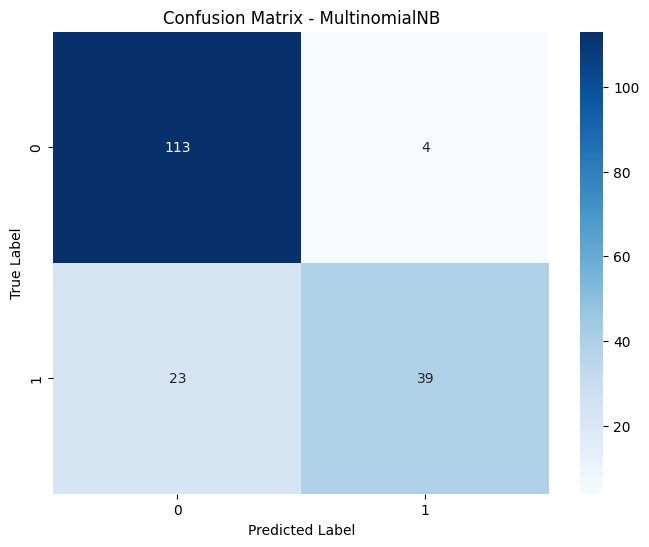


Sample Predictions:
Text: 'well... i just switched to a new htc phone and now chrome forces closed whenever i'm reading mostly ...'
Actual: 0 | Predicted: 0 | Correct: True
--------------------------------------------------
Text: 'the new theme is not compatible with my device :( (samsung galaxy j1) make it compatible please. i r...'
Actual: 0 | Predicted: 0 | Correct: True
--------------------------------------------------
Text: 'good as far as i have it fast and reliable. for now. only thing is that scroll speed is somewhat faa...'
Actual: 1 | Predicted: 1 | Correct: True
--------------------------------------------------
Text: 'keeps crashing ever since i started using it more, it will crash every ten minutes. its starting to ...'
Actual: 0 | Predicted: 0 | Correct: True
--------------------------------------------------
Text: 'suggestion. i given 5 stars to this game,  because i like it very much, but i have a suggestion to i...'
Actual: 1 | Predicted: 0 | Correct: False
---------

In [23]:
# Visualizamos la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nb_model.classes_, 
            yticklabels=nb_model.classes_)
plt.title('Confusion Matrix - MultinomialNB')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ejemplo de predicciones
print("\nSample Predictions:")
for i in range(5):
    actual = y_test.iloc[i]
    predicted = y_test_pred[i]
    text = X_test.iloc[i][:100]  # primeros 100 caracteres
    print(f"Text: '{text}...'")
    print(f"Actual: {actual} | Predicted: {predicted} | Correct: {actual == predicted}")
    print("-" * 50)

### Optimiza el modelo anterior

> Después de entrenar el modelo en sus tres implementaciones, elige la mejor opción y trata de optimizar sus resultados con un random forest

In [24]:
# entrenar Random Forest con parámetros optimizados
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

# entrenar y medir el tiempo del modelo
start_time = time.time()
rf_model.fit(X_train_vec, y_train)
rf_training_time = time.time() - start_time

print(f"Random Forest entrenado en {rf_training_time:.2f} segundos")

Random Forest entrenado en 0.31 segundos


### Comparar Modelos - Naive Bayes vs Random Forest

In [25]:
# Hacer predicciones con Random Forest
rf_test_pred = rf_model.predict(X_test_vec)
rf_test_accuracy = accuracy_score(y_test, rf_test_pred)

# Comparar modelos
print(f"Naive Bayes Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Random Forest Test Accuracy: {rf_test_accuracy:.4f} ({rf_test_accuracy*100:.2f}%)")

# Determina el mejor modelo
if rf_test_accuracy > test_accuracy:
    best_model = rf_model
    best_model_name = "Random Forest"
    best_accuracy = rf_test_accuracy
    improvement = rf_test_accuracy - test_accuracy
    print(f"\n El mejor: Random Forest (+{improvement*100:.2f}%)")
else:
    best_model = nb_model
    best_model_name = "Naive Bayes"
    best_accuracy = test_accuracy
    print(f"\n El mejor: Naive Bayes (Random Forest didn't improve)")

Naive Bayes Test Accuracy: 0.8492 (84.92%)
Random Forest Test Accuracy: 0.7542 (75.42%)

 El mejor: Naive Bayes (Random Forest didn't improve)


### Guardamos el modelo

In [26]:
# Creamos el directorio primero
os.makedirs('../../models/Naive_Bayes', exist_ok=True)

# Guardamos el modelo con pickle
model_path = '../../models/Naive_Bayes/best_model.pkl'
vectorizer_path = '../../models/Naive_Bayes/vectorizer.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)

with open(vectorizer_path, 'wb') as f:
    pickle.dump(vec_model, f)

print(f" Best model ({best_model_name}) saved to: {model_path}")
print(f" Vectorizer saved to: {vectorizer_path}")
print(f" Final accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

 Best model (Naive Bayes) saved to: ../../models/Naive_Bayes/best_model.pkl
 Vectorizer saved to: ../../models/Naive_Bayes/vectorizer.pkl
 Final accuracy: 0.8492 (84.92%)


### Exploramos otras alternativas

In [28]:
# Entrenar y evaluar un modelo SVM
print("Training SVM...")
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_vec, y_train)
svm_accuracy = accuracy_score(y_test, svm_model.predict(X_test_vec))

print(f"SVM Test Accuracy: {svm_accuracy:.4f} ({svm_accuracy*100:.2f}%)")

Training SVM...
SVM Test Accuracy: 0.7877 (78.77%)


### Prueba de regresión logística

In [31]:
print("Entrenamiento de regresion logistica..")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_vec, y_train)
lr_accuracy = accuracy_score(y_test, lr_model.predict(X_test_vec))

print(f"Logistic Regression Test Accuracy: {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")

Entrenamiento de regresion logistica..
Logistic Regression Test Accuracy: 0.8268 (82.68%)


### Prueba de potenciación de Gradiente

In [35]:
print("Entrenando Gradiente Boosting...")
gb_model = GradientBoostingClassifier(
    n_estimators=50, 
    max_depth=3, 
    learning_rate=0.1, 
    random_state=42
)
gb_model.fit(X_train_vec, y_train)
gb_accuracy = accuracy_score(y_test, gb_model.predict(X_test_vec))

print(f"Gradient Boosting Test Accuracy: {gb_accuracy:.4f} ({gb_accuracy*100:.2f}%)")

Entrenando Gradiente Boosting...
Gradient Boosting Test Accuracy: 0.7821 (78.21%)
